2. What is the relationship between stop and search outcomes and crime outcomes across different locations?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
stop = pd.read_csv('stop_and_search.csv')
crimes = pd.read_csv('crimes_and_outcomes.csv')

In [3]:
stop.head()

,Unnamed: 0,age_range,outcome,object_of_search,latitude,longitude,street_id
0,0,25-34,A no further action disposal,Controlled drugs,51.508588,-0.074039,1686590
1,1,25-34,A no further action disposal,Controlled drugs,51.509785,-0.068095,1687860
2,2,over 34,A no further action disposal,Article for use in theft,51.513647,-0.074330,1490955
3,3,over 34,Arrest,Article for use in theft,51.513647,-0.074330,1490955
4,4,25-34,Arrest,Article for use in theft,51.513647,-0.074330,1490955


In [4]:
crimes.head()

,Unnamed: 0,code,name,category,location.latitude,location.longitude,location.street.id
0,0,no-further-action,Investigation complete; no suspect identified,bicycle-theft,51.534795,-0.034636,1692295
1,1,court-result-unavailable,Court result unavailable,drugs,51.526321,-0.063099,1688697
2,2,no-further-action,Investigation complete; no suspect identified,violent-crime,51.525476,-0.024845,1693114
3,3,no-further-action,Investigation complete; no suspect identified,shoplifting,51.519193,-0.075603,1686584
4,4,no-further-action,Investigation complete; no suspect identified,other-theft,51.518258,-0.071498,1687256


In [5]:
crimes = crimes.drop(columns=['Unnamed: 0'])
stop = stop.drop(columns=['Unnamed: 0']);

In [6]:
crimes.columns = ['outcome', 'name', 'category','latitude', 'longitude', 'street_id']

In [7]:
crime_outcomes = list(pd.unique(crimes['outcome']))
crime_outcomes

['no-further-action',
 'court-result-unavailable',
 'unable-to-prosecute',
 'penalty-notice-issued',
 'local-resolution',
 'cautioned',
 'drugs-possession-warning',
 'formal-action-not-in-public-interest']

In [8]:
stop_outcomes= list(pd.unique(stop['outcome']))
stop_outcomes

['A no further action disposal',
 'Arrest',
 'Khat or Cannabis warning',
 'Summons / charged by post',
 'Community resolution',
 'Penalty Notice for Disorder',
 'Caution (simple or conditional)']

In [9]:
outcomes = []
outcomes.append((crime_outcomes[0], stop_outcomes[0], 'no_action'))
outcomes.append((crime_outcomes[2], stop_outcomes[5], 'penalty'))
outcomes.append((crime_outcomes[-3], stop_outcomes[-1], 'caution'))
outcomes.append((crime_outcomes[-2], stop_outcomes[2], 'drug_warning'))
outcomes.append((crime_outcomes[3], stop_outcomes[4], 'local_resolution'))
outcomes.append((crime_outcomes[1], stop_outcomes[1], 'court'))
outcomes.append((crime_outcomes[4], stop_outcomes[3], 'court'))
outcomes.append((crime_outcomes[-1], 0, 'court'))

In [10]:
outcomes

[('no-further-action', 'A no further action disposal', 'no_action'),
 ('unable-to-prosecute', 'Penalty Notice for Disorder', 'penalty'),
 ('cautioned', 'Caution (simple or conditional)', 'caution'),
 ('drugs-possession-warning', 'Khat or Cannabis warning', 'drug_warning'),
 ('penalty-notice-issued', 'Community resolution', 'local_resolution'),
 ('court-result-unavailable', 'Arrest', 'court'),
 ('local-resolution', 'Summons / charged by post', 'court'),
 ('formal-action-not-in-public-interest', 0, 'court')]

In [11]:
crimes_dict = {i[0] : i[2] for i in outcomes}
stop_dict = {i[1] : i[2] for i in outcomes}

In [12]:
stop_dict.pop(0)

'court'

In [13]:
crimes_dict

{'no-further-action': 'no_action',
 'unable-to-prosecute': 'penalty',
 'cautioned': 'caution',
 'drugs-possession-warning': 'drug_warning',
 'penalty-notice-issued': 'local_resolution',
 'court-result-unavailable': 'court',
 'local-resolution': 'court',
 'formal-action-not-in-public-interest': 'court'}

In [14]:
crimes['outcome'] = crimes['outcome'].replace(crimes_dict)

In [15]:
stop['outcome'] = stop['outcome'].replace(stop_dict)

In [16]:
stop

,age_range,outcome,object_of_search,latitude,longitude,street_id
0,25-34,no_action,Controlled drugs,51.508588,-0.074039,1686590
1,25-34,no_action,Controlled drugs,51.509785,-0.068095,1687860
2,over 34,no_action,Article for use in theft,51.513647,-0.074330,1490955
3,over 34,court,Article for use in theft,51.513647,-0.074330,1490955
4,25-34,court,Article for use in theft,51.513647,-0.074330,1490955
...,...,...,...,...,...,...
417,18-24,court,Stolen goods,51.525424,-0.023867,1693544
418,18-24,no_action,Offensive weapons,51.515816,-0.056482,1689527
419,over 34,no_action,Controlled drugs,51.525582,-0.059209,1689219
420,25-34,court,Offensive weapons,51.513763,-0.039015,1691842


In [17]:
crime_agg = crimes.groupby(
    ['latitude', 'longitude', 'outcome']
).size().reset_index(name='crime_count')

In [18]:
crime_agg

,latitude,longitude,outcome,crime_count
0,51.487970,-0.014324,no_action,1
1,51.488019,-0.015618,no_action,2
2,51.488085,-0.010516,no_action,1
3,51.488664,-0.016555,no_action,1
4,51.489206,-0.008191,no_action,4
...,...,...,...,...
1209,51.539332,-0.027923,no_action,1
1210,51.539846,-0.028535,no_action,3
1211,51.540081,-0.023261,no_action,4
1212,51.540393,-0.021546,no_action,3


In [19]:
stop_agg = stop.groupby(
    ['latitude', 'longitude', 'outcome']
).size().reset_index(name='search_count')

In [20]:
stop_agg

,latitude,longitude,outcome,search_count
0,51.487931,-0.012540,no_action,2
1,51.490489,-0.022901,no_action,1
2,51.496340,-0.024304,local_resolution,1
3,51.496828,-0.011158,court,1
4,51.498093,-0.018941,court,1
...,...,...,...,...
252,51.533007,-0.053601,no_action,1
253,51.533358,-0.057970,local_resolution,1
254,51.534337,-0.057322,no_action,2
255,51.539332,-0.027923,court,1


In [21]:
crime_search = crime_agg.merge(stop_agg, on=['latitude', 'longitude', 'outcome'], how='outer').fillna(0)
crime_search

,latitude,longitude,outcome,crime_count,search_count
0,51.487931,-0.012540,no_action,0.0,2.0
1,51.487970,-0.014324,no_action,1.0,0.0
2,51.488019,-0.015618,no_action,2.0,0.0
3,51.488085,-0.010516,no_action,1.0,0.0
4,51.488664,-0.016555,no_action,1.0,0.0
...,...,...,...,...,...
1333,51.539332,-0.027923,no_action,1.0,1.0
1334,51.539846,-0.028535,no_action,3.0,0.0
1335,51.540081,-0.023261,no_action,4.0,0.0
1336,51.540393,-0.021546,no_action,3.0,0.0


In [22]:
import geopandas as gpd
from shapely.geometry import Point

In [23]:
lsoa_gdf = gpd.read_file('LSOA_Dec_2011_Boundaries.geojson')

In [24]:
points = crime_search[['latitude', 'longitude']]

In [25]:
points = points.drop_duplicates()

In [26]:
points

,latitude,longitude
0,51.487931,-0.012540
1,51.487970,-0.014324
2,51.488019,-0.015618
3,51.488085,-0.010516
4,51.488664,-0.016555
...,...,...
1332,51.539332,-0.027923
1334,51.539846,-0.028535
1335,51.540081,-0.023261
1336,51.540393,-0.021546


In [27]:
points_gdf = gpd.GeoDataFrame(
    points,
    geometry=gpd.points_from_xy(points['longitude'], points['latitude'])
)

In [28]:
required_boundaries = gpd.sjoin(
    points_gdf,
    lsoa_gdf,
    how='left',
    predicate='within'
)

/tmp/ipykernel_1461/2865269728.py:1: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  required_boundaries = gpd.sjoin(


In [29]:
required_boundaries = required_boundaries[['latitude', 'longitude', 'geometry', 'LSOA11NM']]

In [30]:
required_boundaries

,latitude,longitude,geometry,LSOA11NM
0,51.487931,-0.012540,POINT (-0.01254 51.48793),Tower Hamlets 030C
1,51.487970,-0.014324,POINT (-0.01432 51.48797),Tower Hamlets 031B
2,51.488019,-0.015618,POINT (-0.01562 51.48802),Tower Hamlets 031B
3,51.488085,-0.010516,POINT (-0.01052 51.48808),Tower Hamlets 030C
4,51.488664,-0.016555,POINT (-0.01656 51.48866),Tower Hamlets 031B
...,...,...,...,...
1332,51.539332,-0.027923,POINT (-0.02792 51.53933),Tower Hamlets 001B
1334,51.539846,-0.028535,POINT (-0.02854 51.53985),Tower Hamlets 001B
1335,51.540081,-0.023261,POINT (-0.02326 51.54008),Tower Hamlets 001C
1336,51.540393,-0.021546,POINT (-0.02155 51.54039),Tower Hamlets 001C


In [31]:
crime_search

,latitude,longitude,outcome,crime_count,search_count
0,51.487931,-0.012540,no_action,0.0,2.0
1,51.487970,-0.014324,no_action,1.0,0.0
2,51.488019,-0.015618,no_action,2.0,0.0
3,51.488085,-0.010516,no_action,1.0,0.0
4,51.488664,-0.016555,no_action,1.0,0.0
...,...,...,...,...,...
1333,51.539332,-0.027923,no_action,1.0,1.0
1334,51.539846,-0.028535,no_action,3.0,0.0
1335,51.540081,-0.023261,no_action,4.0,0.0
1336,51.540393,-0.021546,no_action,3.0,0.0


In [32]:
crime_search = crime_search.merge(required_boundaries, on=['latitude', 'longitude'])

In [33]:
crime_search = crime_search.groupby('LSOA11NM')[['crime_count', 'search_count']].sum().reset_index()

In [34]:
#%reset -f

In [35]:
crime_search

,LSOA11NM,crime_count,search_count
0,City of London 001E,58.0,23.0
1,City of London 001F,2.0,6.0
2,Hackney 022A,15.0,0.0
3,Hackney 022C,4.0,0.0
4,Hackney 023B,9.0,0.0
...,...,...,...
146,Tower Hamlets 032E,5.0,0.0
147,Tower Hamlets 033A,62.0,0.0
148,Tower Hamlets 033B,101.0,10.0
149,Tower Hamlets 033C,14.0,0.0


In [36]:
#crime_search = crime_search[crime_search['search_count'] != crime_search['search_count'].max()]

In [37]:
map_gdf = lsoa_gdf.merge(crime_search, on='LSOA11NM', how='left')

In [38]:
tower_hamlets_statistics = map_gdf[map_gdf['crime_count'].notna()]

In [39]:
df_json = tower_hamlets_statistics.to_json()

In [40]:
pd.qcut(tower_hamlets_statistics['crime_count'], q=10, duplicates='drop')

17      (49.0, 126.0]
35       (31.0, 49.0]
53       (13.0, 17.0]
75       (17.0, 20.0]
133       (8.0, 11.0]
            ...      
5254     (13.0, 17.0]
5330     (11.0, 13.0]
5343     (25.0, 31.0]
5352     (31.0, 49.0]
5397     (20.0, 25.0]
Name: crime_count, Length: 151, dtype: category
Categories (10, interval[float64, right]): [(0.999, 5.0] < (5.0, 8.0] < (8.0, 11.0] < (11.0, 13.0] ... (20.0, 25.0] < (25.0, 31.0] < (31.0, 49.0] < (49.0, 126.0]]

In [41]:
bins = [0,5,8,11,13,17,21,25,32,50,127]

In [42]:
import folium

m = folium.Map(
    location=[51.5, -0.045],
    zoom_start=12,
)


folium.Choropleth(
    geo_data=df_json,
    data=tower_hamlets_statistics,
    columns=['LSOA11NM', 'crime_count'],
    key_on='feature.properties.LSOA11NM',
    fill_color='Reds',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Crime Count',
    highlight=True,
    bins=bins
).add_to(m)


folium.GeoJson(
    df_json,
    style_function=lambda feature: {
        'fillColor': 'transparent',
        'color': 'black',
        'weight': 0.5
    },
    
    tooltip=folium.GeoJsonTooltip(
        fields=['LSOA11NM', 'crime_count', 'search_count'],
        aliases=['LSOA:', 'Crime Count:', 'Searches:']
    )
).add_to(m)
title_html = '''
             <h3 align="center" style="font-size:20px"><b>The Rates of Crime In Different LSOAs of Tower Hamlets</b></h3>
             '''

m.get_root().html.add_child(folium.Element(title_html))

In [43]:
m

In [44]:
pd.qcut(tower_hamlets_statistics['search_count'], q=10, duplicates='drop')

17      (-0.001, 1.0]
35        (7.0, 55.0]
53      (-0.001, 1.0]
75         (2.0, 3.0]
133        (1.0, 2.0]
            ...      
5254    (-0.001, 1.0]
5330       (3.0, 4.0]
5343       (1.0, 2.0]
5352       (1.0, 2.0]
5397    (-0.001, 1.0]
Name: search_count, Length: 151, dtype: category
Categories (6, interval[float64, right]): [(-0.001, 1.0] < (1.0, 2.0] < (2.0, 3.0] < (3.0, 4.0] < (4.0, 7.0] < (7.0, 55.0]]

In [45]:
bins = [0,1,2,3,4,7,55]

In [46]:
m = folium.Map(
    location=[51.5, -0.045],
    zoom_start=12,
)


folium.Choropleth(
    geo_data=df_json,
    data=tower_hamlets_statistics,
    columns=['LSOA11NM', 'search_count'],
    key_on='feature.properties.LSOA11NM',
    fill_color='Reds',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Search Count',
    highlight=True,
    bins=bins
).add_to(m)


folium.GeoJson(
    df_json,
    style_function=lambda feature: {
        'fillColor': 'transparent',
        'color': 'black',
        'weight': 0.5
    },
    
    tooltip=folium.GeoJsonTooltip(
        fields=['LSOA11NM', 'search_count', 'crime_count'],
        aliases=['LSOA:', 'Searches:', 'Crime count:']
    )
).add_to(m)
title_html = '''
             <h3 align="center" style="font-size:20px"><b>The Rates of Stop and Searches In Different LSOAs of Tower Hamlets</b></h3>
             '''

m.get_root().html.add_child(folium.Element(title_html))

In [47]:
m

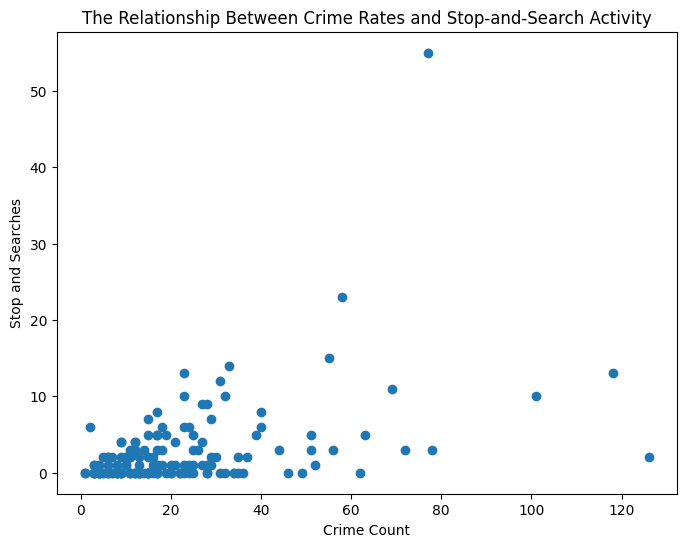

In [48]:
plt.figure(figsize=(8,6))

plt.scatter(
    tower_hamlets_statistics['crime_count'],
    tower_hamlets_statistics['search_count']
    
)

plt.xlabel('Crime Count')
plt.ylabel('Stop and Searches')
plt.title('The Relationship Between Crime Rates and Stop-and-Search Activity')

plt.show()

In [49]:
tower_hamlets_statistics['crime_count'].corr(tower_hamlets_statistics['search_count'])

0.4421476269197425